In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
upload = files.upload()


Saving heart.csv to heart (1).csv


In [ ]:
file_path = '/content/heart.csv'
df = pd.read_csv(file_path)
df.head(10)

,S,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [38]:
df.shape

(918, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   S               918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
null_values = df.isnull().sum()
print("Number of Null values: ",null_values)

Number of Null values:  S                 0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print("Before Cleaning")
df.describe()

Before Cleaning


,S,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
chol = df[df['Cholesterol'] == 0]
chol_total = chol['Cholesterol'].count()
print("Total number of cholestrol: ",chol_total)

bp = df[df['RestingBP'] == 0]
bp_total = bp['RestingBP'].count()
print("Total number of RestingBP: ",bp_total)

Total number of cholestrol:  172
Total number of RestingBP:  1


In [ ]:
chol = df[df['Cholesterol'] != 0]
chol_mean = chol['Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0,round(chol_mean))

bp = df[df['RestingBP'] != 0]
bp_mean = bp['RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,round(bp_mean))

In [ ]:
print("After Cleaning")
df.describe()

After Cleaning


,S,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.541394,244.703704,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.989938,53.318219,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,245.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
numeric = df.select_dtypes(include = ['int64','float64']).columns
categorical = df.select_dtypes(include = ['object','category']).columns
print("Numeric Columns: ",numeric)
print("Categorical Columns: ",categorical)

Numeric Columns:  Index(['S', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')
Categorical Columns:  Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [ ]:
df.head()

,S,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<Axes: xlabel='RestingBP', ylabel='Count'>

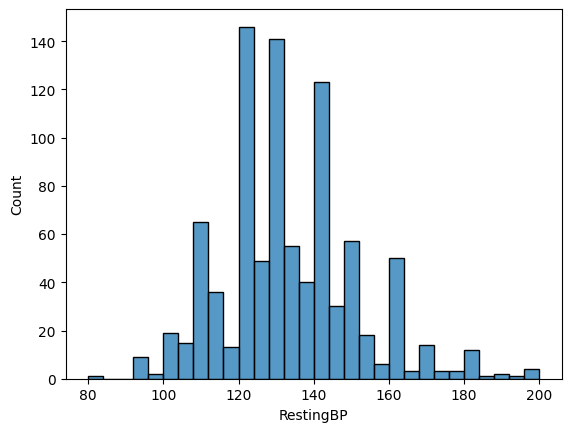

In [ ]:
sns.histplot(df['RestingBP'])

<Axes: xlabel='Cholesterol', ylabel='Count'>

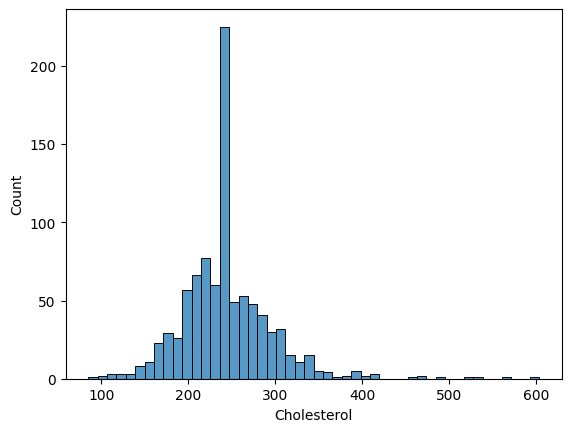

In [ ]:
sns.histplot(df['Cholesterol'])

<Axes: xlabel='MaxHR', ylabel='Count'>

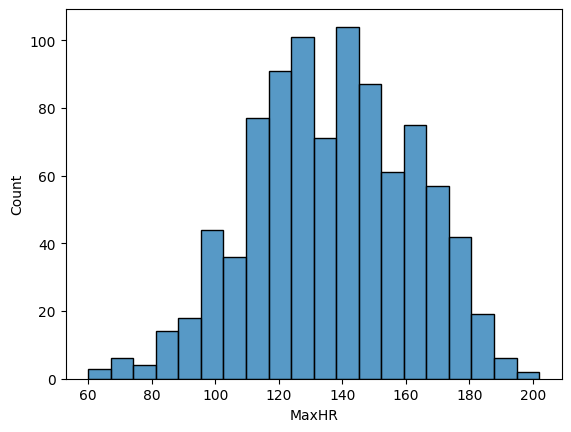

In [ ]:
sns.histplot(df['MaxHR'])

<Axes: xlabel='Oldpeak', ylabel='Count'>

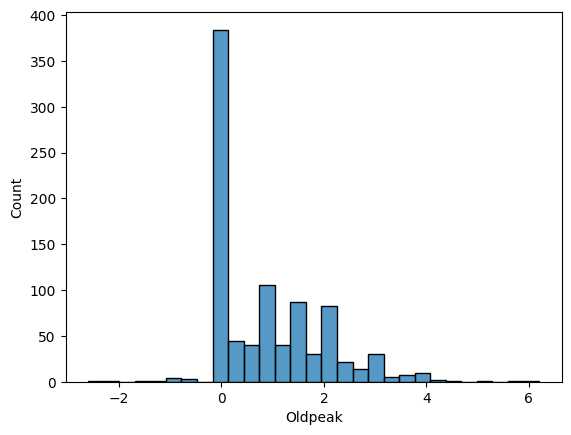

In [ ]:
sns.histplot(df['Oldpeak'])

In [40]:
df.head()

,S,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<Axes: xlabel='ChestPainType', ylabel='count'>

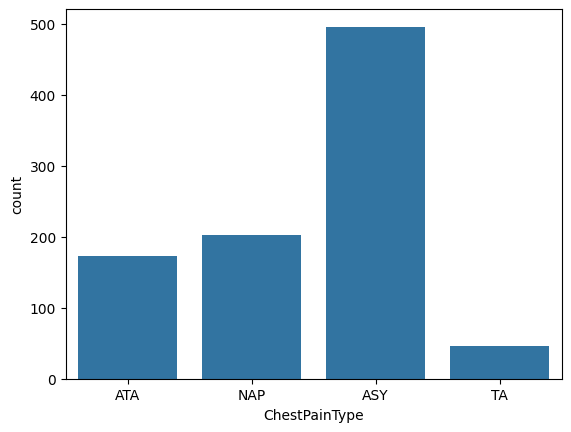

In [ ]:
sns.countplot(x = df['ChestPainType'],data = df)

<Axes: xlabel='RestingECG', ylabel='count'>

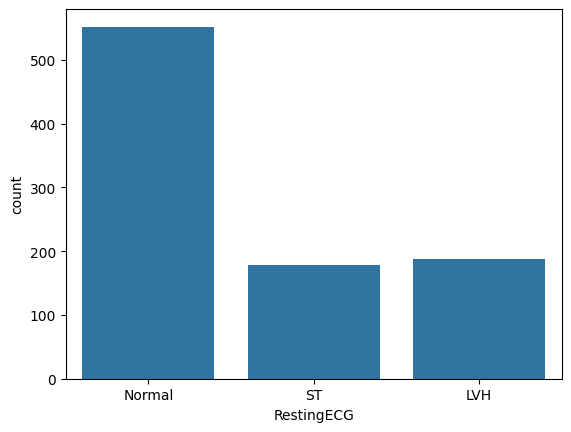

In [42]:
sns.countplot(x = df['RestingECG'],data=df)

<Axes: xlabel='ExerciseAngina', ylabel='count'>

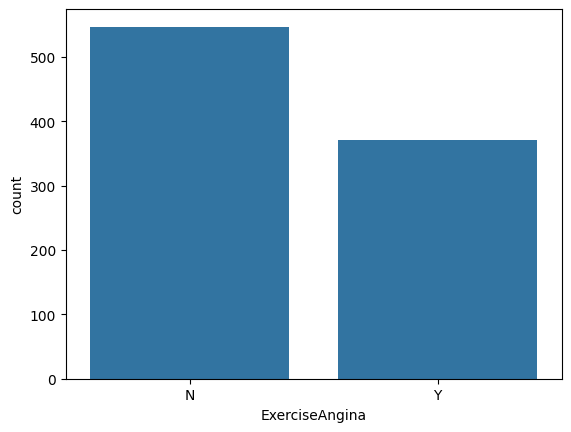

In [43]:
sns.countplot(x = df['ExerciseAngina'],data=df)

<Axes: xlabel='ST_Slope', ylabel='count'>

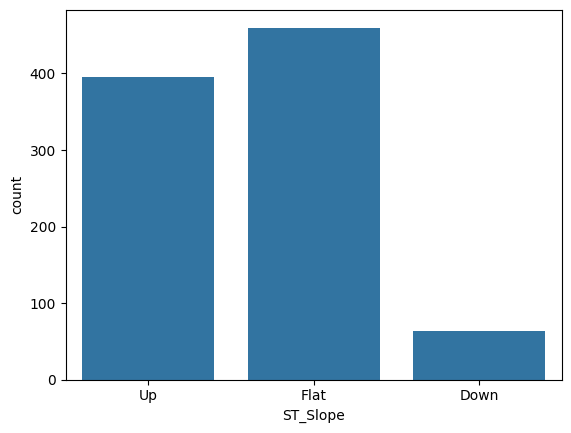

In [44]:
sns.countplot(x = df['ST_Slope'],data=df)

<Axes: xlabel='HeartDisease', ylabel='count'>

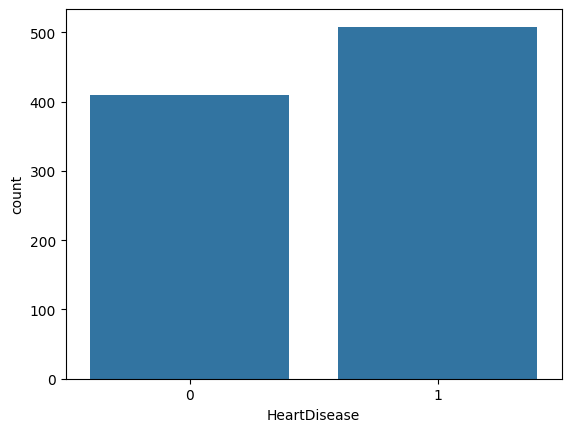

In [45]:
sns.countplot(x = df['HeartDisease'],data=df)

<Axes: xlabel='Sex', ylabel='count'>

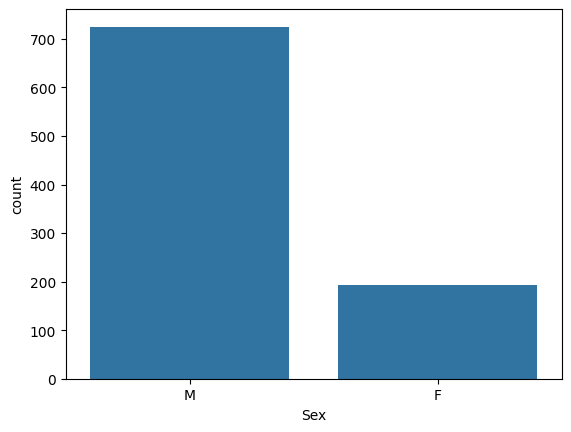

In [47]:
sns.countplot(x = df['Sex'],data=df)

<Axes: >

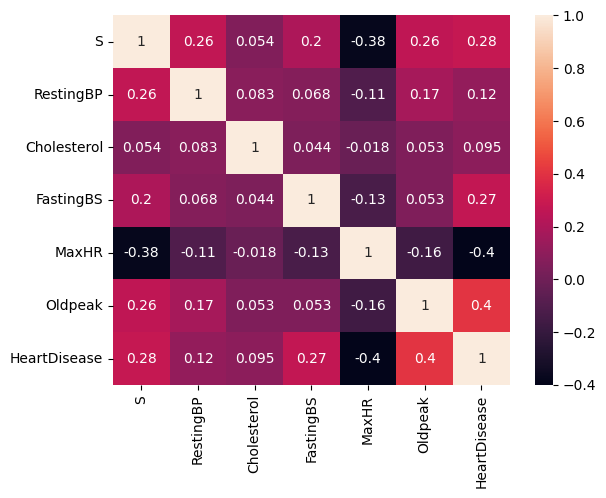

In [48]:
sns.heatmap(df.corr(numeric_only = True),annot = True)

In [49]:
df_encoded = pd.get_dummies(data=df)
df_encoded.head()

,S,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [50]:
df_encoded = df_encoded.astype(int)
df_encoded.head()

,S,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [51]:
df_encoded.shape

(918, 21)

In [52]:
df_encoded.columns

Index(['S', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [53]:
x = df_encoded.drop('HeartDisease',axis=1)
y = df_encoded['HeartDisease']

In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_x = pd.DataFrame(scaler.fit_transform(x),columns = x.columns)
scaled_x

,S,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414825,0.831244,-0.551341,1.382928,-0.727592,-0.515952,0.515952,-1.084138,2.075177,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,0.823556,-0.823556,-0.271448,-1.002181,1.150674
1,-0.478484,1.527163,-1.214200,-0.551341,0.754157,0.282891,1.938163,-1.938163,-1.084138,-0.481887,1.876744,-0.229679,-0.507478,0.814275,-0.490449,0.823556,-0.823556,-0.271448,0.997824,-0.869056
2,-1.751359,-0.141345,0.718651,-0.551341,-1.525138,-0.727592,-0.515952,0.515952,-1.084138,2.075177,-0.532838,-0.229679,-0.507478,-1.228087,2.038947,0.823556,-0.823556,-0.271448,-1.002181,1.150674
3,-0.584556,0.303591,-0.576172,-0.551341,-1.132156,0.282891,1.938163,-1.938163,0.922392,-0.481887,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,-1.214246,1.214246,-0.271448,0.997824,-0.869056
4,0.051881,0.970994,-0.932717,-0.551341,-0.581981,-0.727592,-0.515952,0.515952,-1.084138,-0.481887,1.876744,-0.229679,-0.507478,0.814275,-0.490449,0.823556,-0.823556,-0.271448,-1.002181,1.150674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253683,0.362105,-0.551341,-0.188999,0.282891,-0.515952,0.515952,-1.084138,-0.481887,-0.532838,4.353909,-0.507478,0.814275,-0.490449,0.823556,-0.823556,-0.271448,0.997824,-0.869056
914,1.536902,0.637292,-0.970248,1.813758,0.164684,2.303858,-0.515952,0.515952,0.922392,-0.481887,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,0.823556,-0.823556,-0.271448,0.997824,-0.869056
915,0.370100,-0.141345,-2.133711,-0.551341,-0.857069,0.282891,-0.515952,0.515952,0.922392,-0.481887,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,-1.214246,1.214246,-0.271448,0.997824,-0.869056
916,0.370100,-0.141345,-0.163330,-0.551341,1.461525,-0.727592,1.938163,-1.938163,-1.084138,2.075177,-0.532838,-0.229679,1.970528,-1.228087,-0.490449,0.823556,-0.823556,-0.271448,0.997824,-0.869056


In [74]:
from numpy.random import random_integers
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(scaled_x,y,test_size=0.20,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(734, 20)
(184, 20)
(734,)
(184,)


In [75]:
from sklearn.linear_model import LogisticRegression
ls = LogisticRegression()
model = ls.fit(x_train,y_train)

In [76]:
y_pred = ls.predict(x_test)

In [77]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Confusion_matrix: \n",confusion_matrix(y_test,y_pred))

Confusion_matrix: 
 [[68  9]
 [16 91]]


In [78]:
print("Classification_Report: \n",classification_report(y_test,y_pred))


Classification_Report: 
               precision    recall  f1-score   support

           0       0.81      0.88      0.84        77
           1       0.91      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



In [79]:
import joblib
joblib.dump(model,"heart_model.pkl")
joblib.dump(scaled_x,"scaler.pkl")
joblib.dump(df_encoded.columns,"columns.pkl")
#

['columns.pkl']

## Heart Disease Prediction Project

### Project Overview

This notebook demonstrates an end-to-end machine learning pipeline for predicting heart disease using a dataset containing various health-related features.

### Data Source
The dataset used in this analysis is `heart.csv`, uploaded from the local system.

### Notebook Steps
1.  **Load Data**: The `heart.csv` dataset is loaded into a pandas DataFrame.
2.  **Initial Data Exploration**: Basic checks are performed, including displaying the head, shape, info, null values, and duplicates.
3.  **Data Cleaning**:
    *   Identified and handled zero values in 'Cholesterol' and 'RestingBP' by replacing them with the mean of their respective non-zero values.
4.  **Feature Engineering**: Categorical features are one-hot encoded using `pd.get_dummies`.
5.  **Data Scaling**: Numerical features are scaled using `StandardScaler`.
6.  **Model Training**: A Logistic Regression model is trained on the preprocessed data.
7.  **Model Evaluation**: The model's performance is evaluated using a confusion matrix and classification report.
8.  **Model Export**: The trained model, scaler, and column names are saved using `joblib` for future deployment.


In [ ]:
readme_content = """
# Heart Disease Prediction Project

## Project Overview

This notebook demonstrates an end-to-end machine learning pipeline for predicting heart disease using a dataset containing various health-related features.

### Data Source
The dataset used in this analysis is `heart.csv`, uploaded from the local system.

### Notebook Steps
1.  **Load Data**: The `heart.csv` dataset is loaded into a pandas DataFrame.
2.  **Initial Data Exploration**: Basic checks are performed, including displaying the head, shape, info, null values, and duplicates.
3.  **Data Cleaning**:
    *   Identified and handled zero values in 'Cholesterol' and 'RestingBP' by replacing them with the mean of their respective non-zero values.
4.  **Feature Engineering**: Categorical features are one-hot encoded using `pd.get_dummies`.
5.  **Data Scaling**: Numerical features are scaled using `StandardScaler`.
6.  **Model Training**: A Logistic Regression model is trained on the preprocessed data.
7.  **Model Evaluation**: The model's performance is evaluated using a confusion matrix and classification report.
8.  **Model Export**: The trained model, scaler, and column names are saved using `joblib` for future deployment.
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print('README.md created successfully!')